In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [265]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

# Downloaded IDEA data

Downloaded from https://idea.research.calicolabs.com/data

In [266]:
idea_kinetics = pd.read_csv("../../../data/idea_kinetics.tsv", sep = "\t")
idea_kinetics

,tc_id,model,rate,t_fall,t_rise,v_final,v_inter,GeneName,exp_id,TF
0,1,sigmoid,0.258761,NaN,44.763805,NaN,0.653032,AAD10,1,ACA1
1,2,sigmoid,0.126136,NaN,45.535603,NaN,-2.109710,AAP1,1,ACA1
2,3,sigmoid,0.083823,NaN,22.377916,NaN,-0.615029,AAT1,1,ACA1
3,4,sigmoid,0.064759,NaN,29.290289,NaN,-0.620696,ABF1,1,ACA1
4,5,sigmoid,1.174821,NaN,3.653315,NaN,5.377406,ACA1,1,ACA1
...,...,...,...,...,...,...,...,...,...,...
100031,100032,sigmoid,1.014049,NaN,2.947076,NaN,-1.460898,YGL152C,217,ZNF1
100032,100033,sigmoid,0.715342,NaN,9.862979,NaN,-0.414272,YHK8,217,ZNF1
100033,100034,sigmoid,1.217390,NaN,6.739437,NaN,0.960504,YJL086C,217,ZNF1
100034,100035,sigmoid,1.115343,NaN,17.460293,NaN,-1.514096,YOR146W,217,ZNF1


In [267]:
def get_half_max_time(row):
    if row['model'] == 'sigmoid':
        return row['t_rise']
    elif row['model'] == 'impulse':
        # two half-max times; return both or just the rising one depending on your use case
        return row['t_rise']  # or t_fall, or min/mean of both

idea_kinetics['half_max_time'] = idea_kinetics.apply(get_half_max_time, axis=1)
idea_kinetics["half_max_time"] = 1 / idea_kinetics["half_max_time"]
idea_kinetics

,tc_id,model,rate,t_fall,t_rise,v_final,v_inter,GeneName,exp_id,TF,half_max_time
0,1,sigmoid,0.258761,NaN,44.763805,NaN,0.653032,AAD10,1,ACA1,0.022339
1,2,sigmoid,0.126136,NaN,45.535603,NaN,-2.109710,AAP1,1,ACA1,0.021961
2,3,sigmoid,0.083823,NaN,22.377916,NaN,-0.615029,AAT1,1,ACA1,0.044687
3,4,sigmoid,0.064759,NaN,29.290289,NaN,-0.620696,ABF1,1,ACA1,0.034141
4,5,sigmoid,1.174821,NaN,3.653315,NaN,5.377406,ACA1,1,ACA1,0.273724
...,...,...,...,...,...,...,...,...,...,...,...
100031,100032,sigmoid,1.014049,NaN,2.947076,NaN,-1.460898,YGL152C,217,ZNF1,0.339319
100032,100033,sigmoid,0.715342,NaN,9.862979,NaN,-0.414272,YHK8,217,ZNF1,0.101389
100033,100034,sigmoid,1.217390,NaN,6.739437,NaN,0.960504,YJL086C,217,ZNF1,0.148380
100034,100035,sigmoid,1.115343,NaN,17.460293,NaN,-1.514096,YOR146W,217,ZNF1,0.057273


In [268]:
len(idea_kinetics["GeneName"].unique())

6166

# Aggregating TF target speeds

In [269]:
def aggregate_kinetics(df, col, prefix, cv_threshold=0.5):
    result = (
        df.groupby("TF")[col]
        .agg(
            **{f"{prefix}_mean":         'mean'},
            **{f"{prefix}_std":          'std'},
            **{f"{prefix}_median":       'median'},
            **{f"{prefix}_max":          'max'},
            **{f"{prefix}_top5_mean":    lambda x: x.nlargest(5).mean()},
            **{f"n_targets":             'count'},
        )
        .reset_index()
        .rename(columns={"TF": "gene"})
    )

    result["cv"] = result[f"{prefix}_std"] / result[f"{prefix}_mean"].abs()

    cols_to_mask = [c for c in result.columns if c.startswith(prefix)]
    result.loc[result["cv"] > cv_threshold, cols_to_mask] = pd.NA

    return result


tf_kinetics_halfmax = aggregate_kinetics(idea_kinetics, "half_max_time", "half_max")
tf_kinetics_rate    = aggregate_kinetics(idea_kinetics, "rate",          "rate")

tf_kinetics = tf_kinetics_halfmax.merge(
    tf_kinetics_rate.drop(columns=["n_targets", "cv"]),
    on="gene"
)
tf_kinetics

,gene,half_max_mean,half_max_std,half_max_median,half_max_max,half_max_top5_mean,n_targets,cv,rate_mean,rate_std,rate_median,rate_max,rate_top5_mean
0,ACA1,NaN,NaN,NaN,NaN,NaN,772,0.896240,NaN,NaN,NaN,NaN,NaN
1,ACE2,NaN,NaN,NaN,NaN,NaN,529,0.770666,NaN,NaN,NaN,NaN,NaN
2,ADA2,NaN,NaN,NaN,NaN,NaN,67,0.854958,NaN,NaN,NaN,NaN,NaN
3,ADR1,NaN,NaN,NaN,NaN,NaN,135,1.590722,NaN,NaN,NaN,NaN,NaN
4,AFT1,0.044637,0.022055,0.043582,0.415194,0.225566,1183,0.494098,0.328086,0.118077,0.330993,1.193047,0.945100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,YRM1,NaN,NaN,NaN,NaN,NaN,62,1.155719,NaN,NaN,NaN,NaN,NaN
199,YRR1,NaN,NaN,NaN,NaN,NaN,119,0.751952,NaN,NaN,NaN,NaN,NaN
200,Z3EV,NaN,NaN,NaN,NaN,NaN,38,0.774929,NaN,NaN,NaN,NaN,NaN
201,ZAP1,NaN,NaN,NaN,NaN,NaN,889,0.798812,NaN,NaN,NaN,NaN,NaN


# Loading in trebl speeds

In [270]:
trebl_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/aggreg_per_TF.csv", index_col = 0)
trebl_speeds

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136
...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682


# Comparing speeds

In [271]:
import pandas as pd
from scipy import stats

merged = tf_kinetics.merge(trebl_speeds, on='gene')

kinetics_cols = [
    'half_max_mean', 'half_max_median', 'half_max_trimmed_mean',
    'rate_mean', 'rate_median', 'rate_max',
    'rate_top5_mean', 'rate_trimmed_mean',
]
speed_cols = [
    'max_speed', 'mean_speed', 
    'median_speed', 'top3_mean_speed',
]

rows = []
for k in kinetics_cols:
    for s in speed_cols:
        if k not in merged.columns:
            continue
        tmp = merged[[k, s]].dropna()
        r, p = stats.spearmanr(tmp[k], tmp[s])
        rows.append({'kinetics': k, 'trebl_speed': s, 'r': r, 'p': p, 'n': len(tmp)})

corr_df = pd.DataFrame(rows).sort_values('p', key=abs, ascending=True)
display(corr_df)

,kinetics,trebl_speed,r,p,n
8,rate_mean,max_speed,0.614035,0.006711,18
12,rate_median,max_speed,0.595459,0.009126,18
11,rate_mean,top3_mean_speed,0.593395,0.009433,18
15,rate_median,top3_mean_speed,0.589267,0.010071,18
20,rate_top5_mean,max_speed,0.442724,0.065782,18
9,rate_mean,mean_speed,0.415893,0.086056,18
13,rate_median,mean_speed,0.405573,0.094953,18
22,rate_top5_mean,median_speed,0.384933,0.114708,18
10,rate_mean,median_speed,0.380805,0.118984,18
21,rate_top5_mean,mean_speed,0.374613,0.125608,18


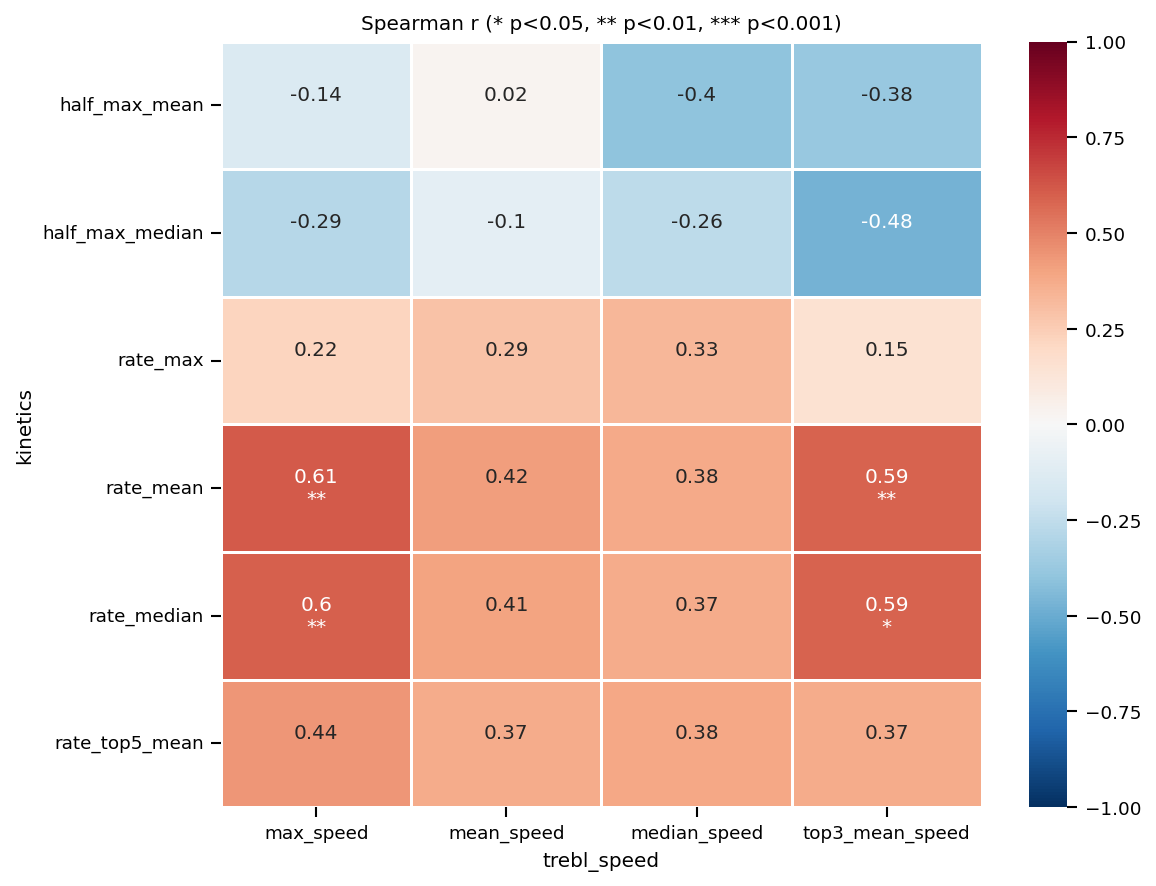

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context('paper')
pivot_r = corr_df.pivot(index='kinetics', columns='trebl_speed', values='r')
pivot_p = corr_df.pivot(index='kinetics', columns='trebl_speed', values='p')

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

annot = pivot_r.round(2).astype(str) + '\n' + pivot_p.applymap(sig_stars)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
sns.heatmap(
    pivot_r, annot=annot, fmt='', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Spearman r (* p<0.05, ** p<0.01, *** p<0.001)')
plt.tight_layout()

In [275]:
pivot_r = pivot_r.dropna(thresh=len(speed_labels)//2 + 1)
pivot_p = pivot_p.loc[pivot_r.index]


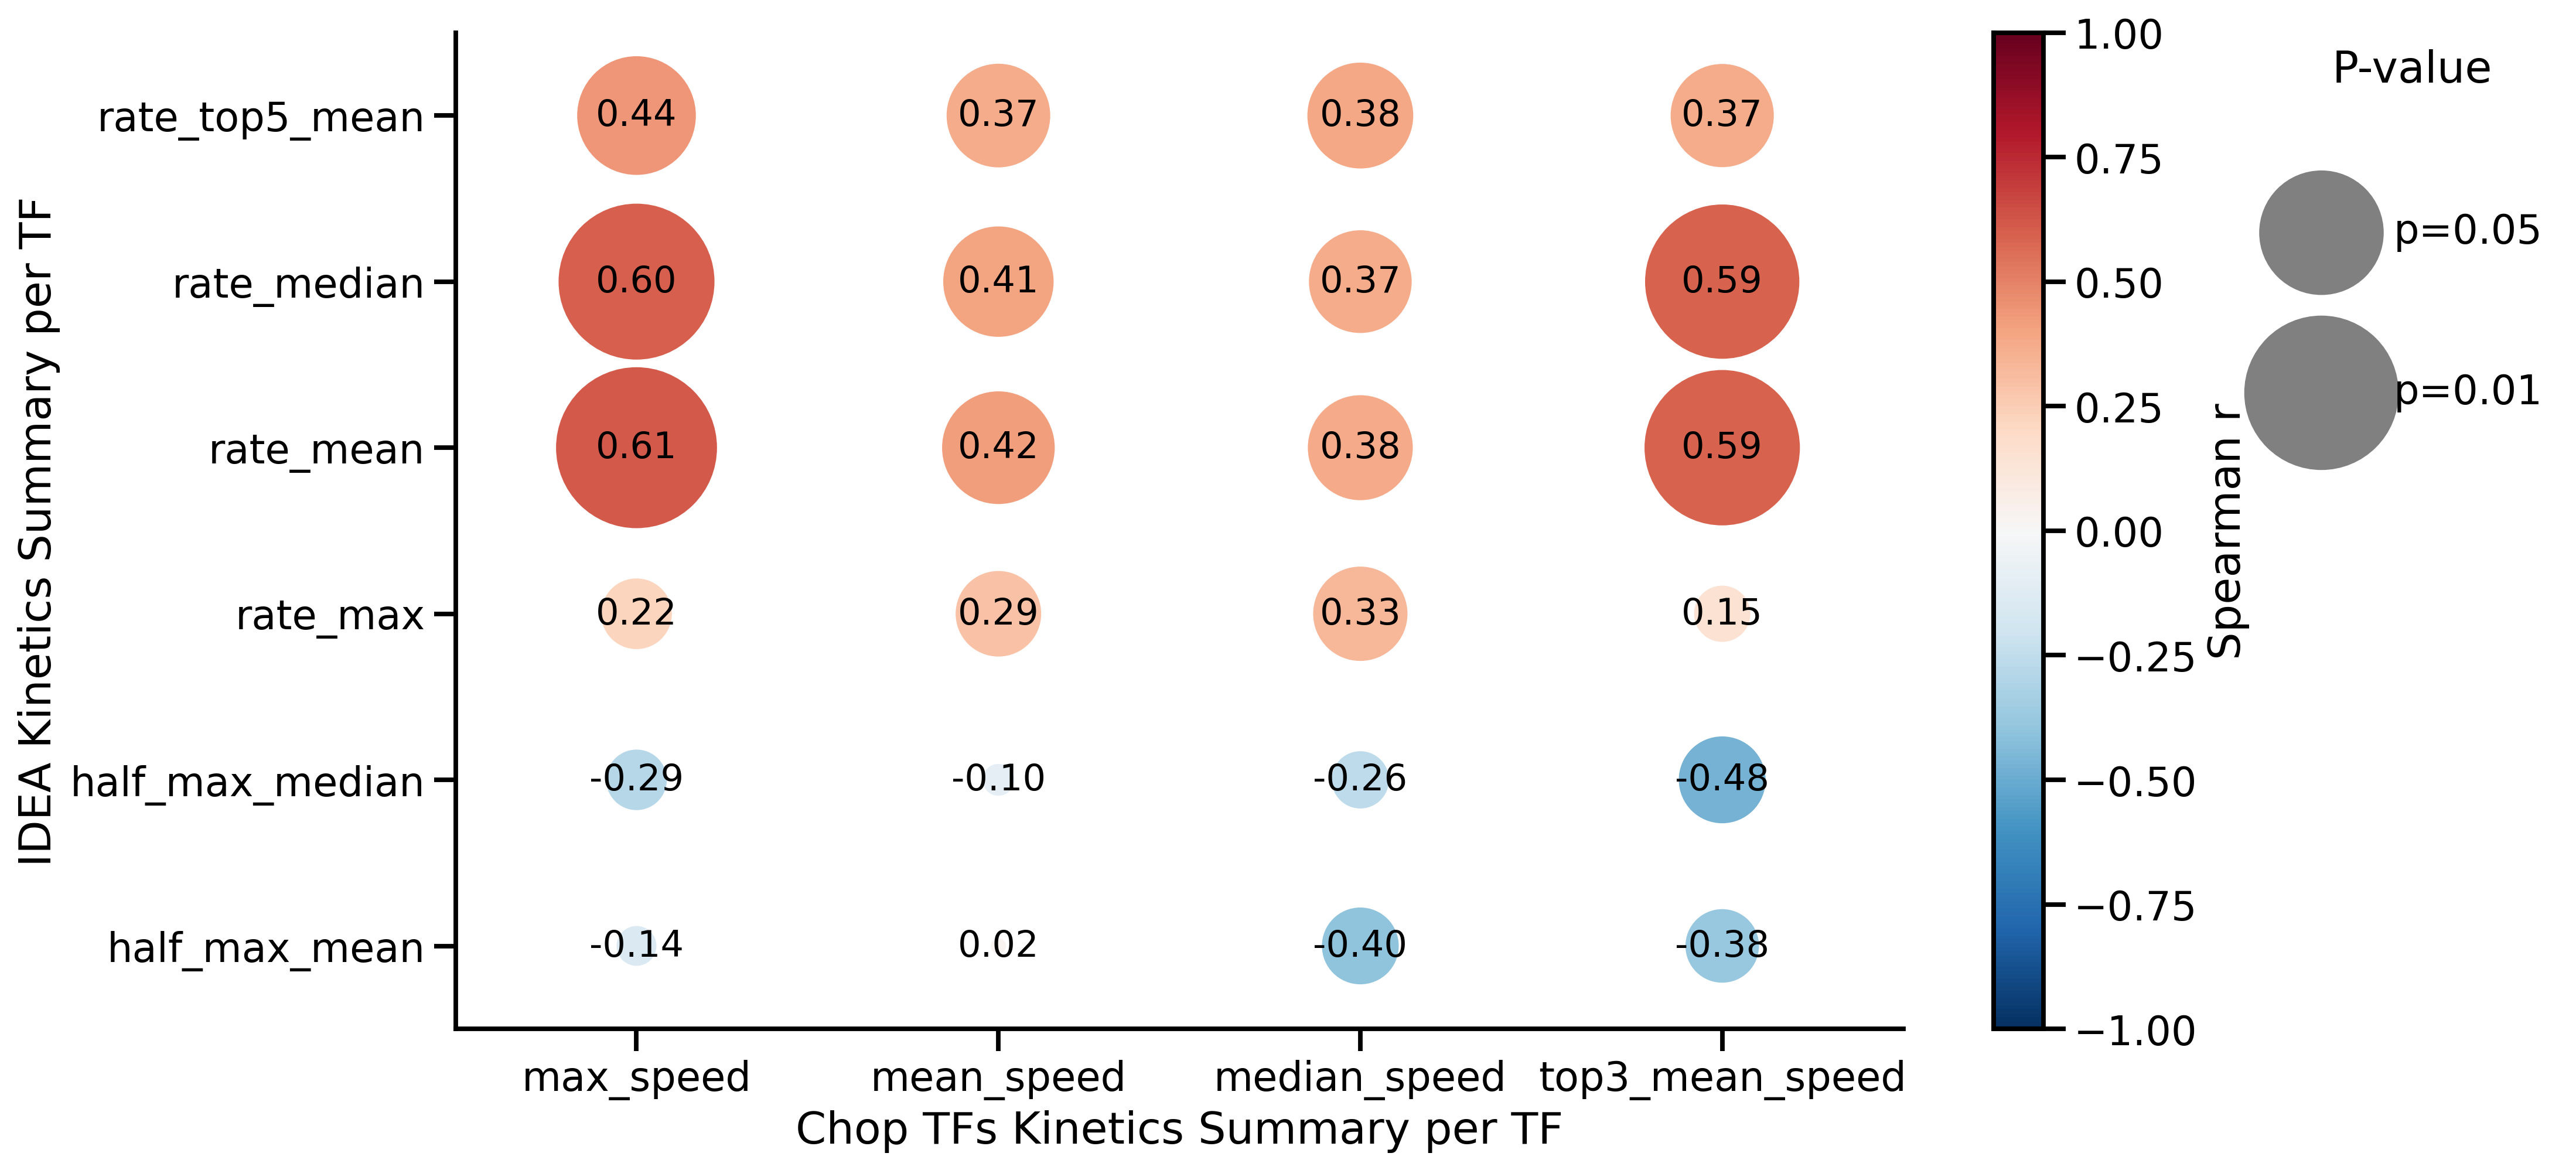

In [276]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
sns.set_context('talk')

kinetics_labels = pivot_r.index.tolist()
speed_labels    = pivot_r.columns.tolist()

xs, ys, colors, sizes, annots = [], [], [], [], []
for i, k in enumerate(kinetics_labels):
    for j, s in enumerate(speed_labels):
        r = pivot_r.loc[k, s]
        p = pivot_p.loc[k, s]
        xs.append(j)
        ys.append(i)
        colors.append(r)
        sizes.append(-np.log10(p) * 2000)
        annots.append(f'{r:.2f}')

cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-1, vmax=1)

fig, ax = plt.subplots(figsize=(15,7), dpi=300)
sc = ax.scatter(xs, ys, c=colors, s=sizes, cmap=cmap, norm=norm,
                edgecolors='none', linewidths=0.4)

for x, y, txt in zip(xs, ys, annots):
    ax.text(x, y, txt, ha='center', va='center', fontsize='small')

plt.colorbar(sc, ax=ax, label='Spearman r')

# size legend using representative p-values
for p_val, label in [(0.05, 'p=0.05'), (0.01, 'p=0.01')]:
    ax.scatter([], [], s=-np.log10(p_val) * 2000,
               color='grey', edgecolors='none', label=label)
ax.legend(title='P-value', frameon=False, loc='upper left',
          bbox_to_anchor=(1.25, 1), borderaxespad=0, labelspacing=3)

ax.set_xticks(range(len(speed_labels)))
ax.set_xticklabels(speed_labels)
ax.set_yticks(range(len(kinetics_labels)))
ax.set_yticklabels(kinetics_labels)
ax.set_xlim(-0.5, len(speed_labels) - 0.5)
ax.set_ylim(-0.5, len(kinetics_labels) - 0.5)

ax.set_xlabel("Chop TFs Kinetics Summary per TF")
ax.set_ylabel("IDEA Kinetics Summary per TF")

sns.despine()
plt.tight_layout()

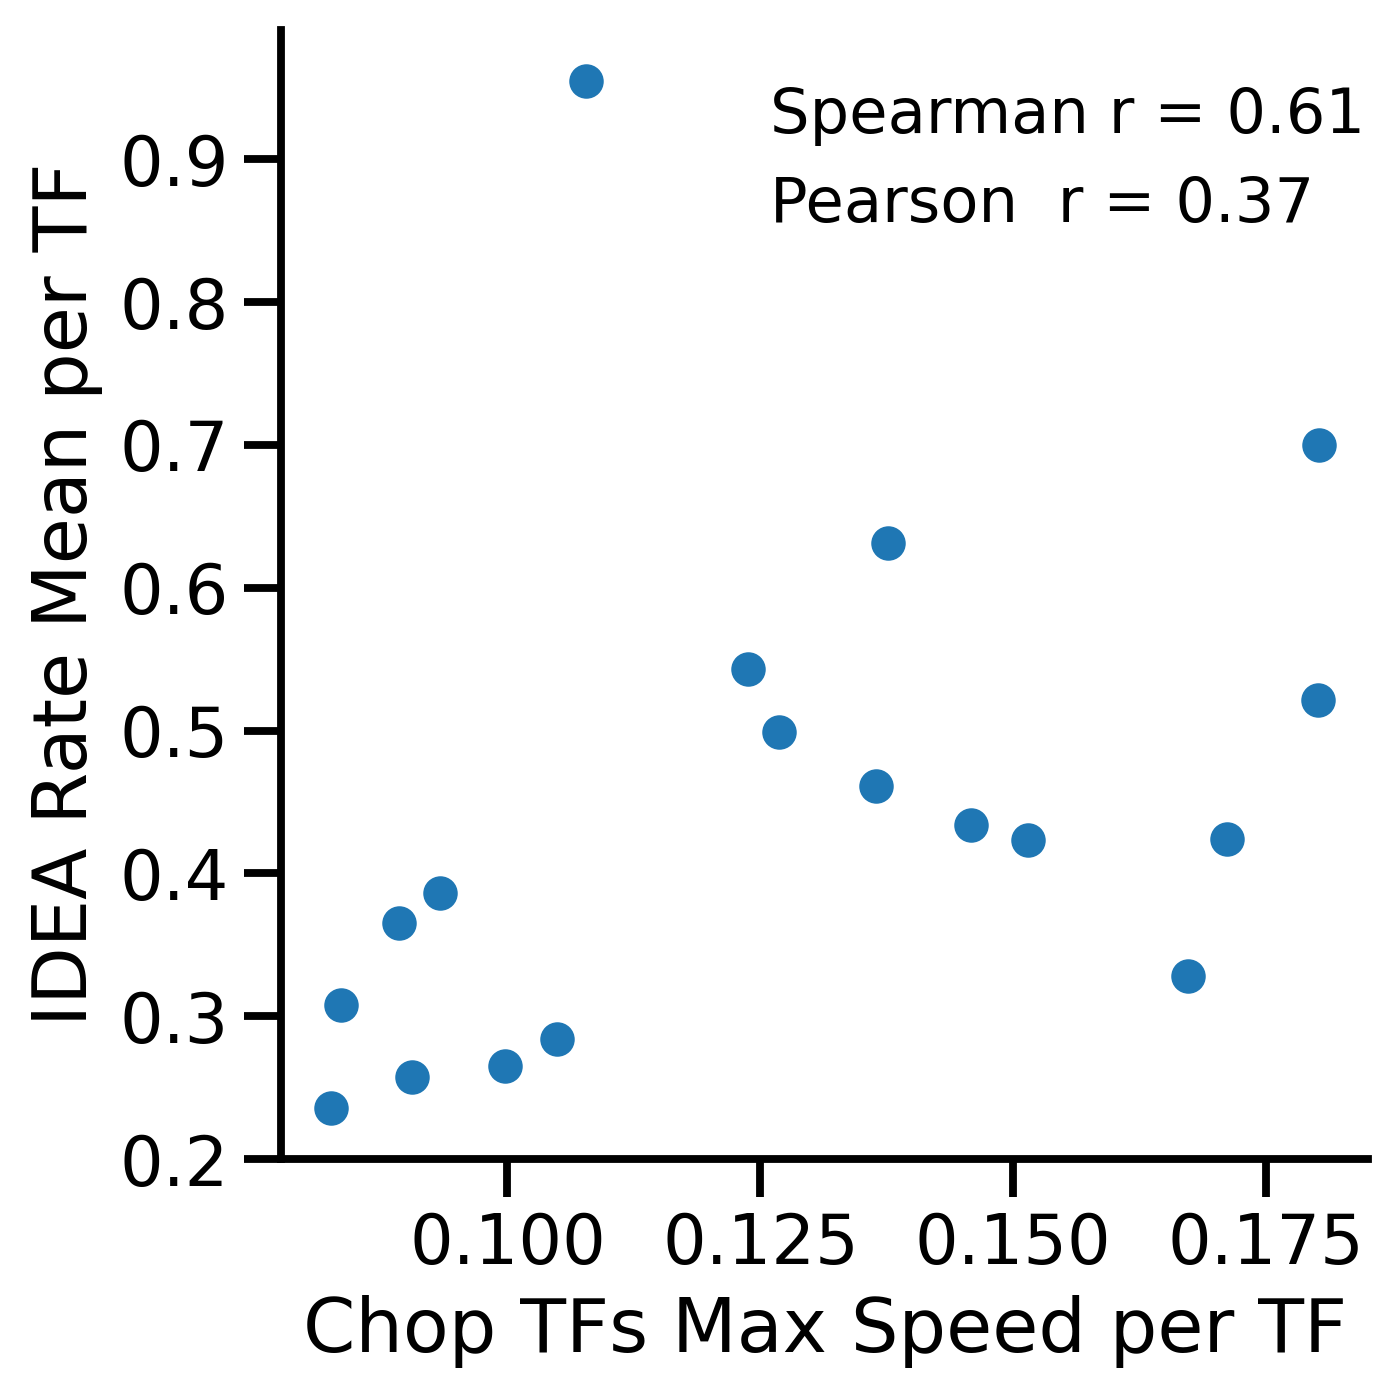

In [277]:
from scipy import stats

tmp = merged[["max_speed", "rate_mean"]].dropna()
r_sp, p_sp = stats.spearmanr(tmp["max_speed"], tmp["rate_mean"])
r_pe, p_pe = stats.pearsonr(tmp["max_speed"],  tmp["rate_mean"])

fig, ax = plt.subplots(figsize=(5,5), dpi=300)
sns.scatterplot(data=merged, x="max_speed", y="rate_mean", ax=ax)

ax.text(
    0.45, 0.95,
    f"Spearman r = {r_sp:.2f}\nPearson  r = {r_pe:.2f}",
    transform=ax.transAxes, va='top', ha='left', fontsize='small',
    linespacing=1.6,
)

ax.set_ylabel("IDEA Rate Mean per TF")
ax.set_xlabel("Chop TFs Max Speed per TF")
sns.despine()
plt.tight_layout()

In [116]:
average_TF_rates = (
    idea_kinetics
    .groupby("TF")[["rate", "half_max"]]
    .agg(["mean", "std"])
    .reset_index()
)

# flatten multi-index columns
average_TF_rates.columns = [
    "_".join(col).strip("_")
    for col in average_TF_rates.columns
]

# rename columns
average_TF_rates = average_TF_rates.rename(columns={
    "TF": "gene",
    "rate_mean": "idea_rate_mean",
    "rate_std": "idea_rate_std",
    "half_max_mean": "idea_half_max_mean",
    "half_max_std": "idea_half_max_std",
})

average_TF_rates

,gene,idea_rate_mean,idea_rate_std,idea_half_max_mean,idea_half_max_std
0,ACA1,0.238840,0.164639,0.033373,0.029910
1,ACE2,0.271665,0.157909,0.045285,0.034899
2,ADA2,0.374563,0.240011,0.061820,0.052853
3,ADR1,0.279771,0.204716,0.067118,0.106766
4,AFT1,0.328086,0.118077,0.044637,0.022055
...,...,...,...,...,...
198,YRM1,0.343128,0.309187,0.037605,0.043460
199,YRR1,0.521114,0.420281,0.052654,0.039594
200,Z3EV,0.670895,0.363673,0.176464,0.136747
201,ZAP1,0.419462,0.239784,0.058510,0.046738


In [117]:
trebl_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/aggreg_per_TF.csv", index_col = 0)
trebl_speeds["top3_half_max"] = 1 / trebl_speeds["top3_mean_speed"]
trebl_speeds

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,top3_half_max
0,ABF1,0.084093,0.073370,0.074495,0.077694,0.011716,4.0,0.511364,12.870990
1,ACA1,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818,12.477178
2,ACE2,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,6.724654
3,ADR1,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926,6.492688
4,AFT1,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136,6.986966
...,...,...,...,...,...,...,...,...,...
143,WAR1,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955,6.708348
144,XBP1,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455,12.230064
145,YAP1,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000,7.504083
152,YRM1,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682,8.292879


In [118]:
idea_trebl_merge = pd.merge(average_TF_rates, trebl_speeds)
#idea_trebl_merge["idea_cv"] = idea_trebl_merge["idea_std"] / idea_trebl_merge["idea_mean"]
idea_trebl_merge

,gene,idea_rate_mean,idea_rate_std,idea_half_max_mean,idea_half_max_std,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,top3_half_max
0,ACA1,0.238840,0.164639,0.033373,0.029910,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818,12.477178
1,ACE2,0.271665,0.157909,0.045285,0.034899,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,6.724654
2,ADR1,0.279771,0.204716,0.067118,0.106766,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926,6.492688
3,AFT1,0.328086,0.118077,0.044637,0.022055,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136,6.986966
4,AFT2,0.232428,0.215627,0.041396,0.029549,0.157942,0.111964,0.107917,0.137785,0.026063,8.0,0.823864,7.257702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,WAR1,0.260614,0.227934,0.039558,0.044084,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955,6.708348
61,XBP1,0.257143,0.118102,0.052017,0.034122,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455,12.230064
62,YAP1,0.463372,0.259150,0.061684,0.039944,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000,7.504083
63,YRM1,0.343128,0.309187,0.037605,0.043460,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682,8.292879


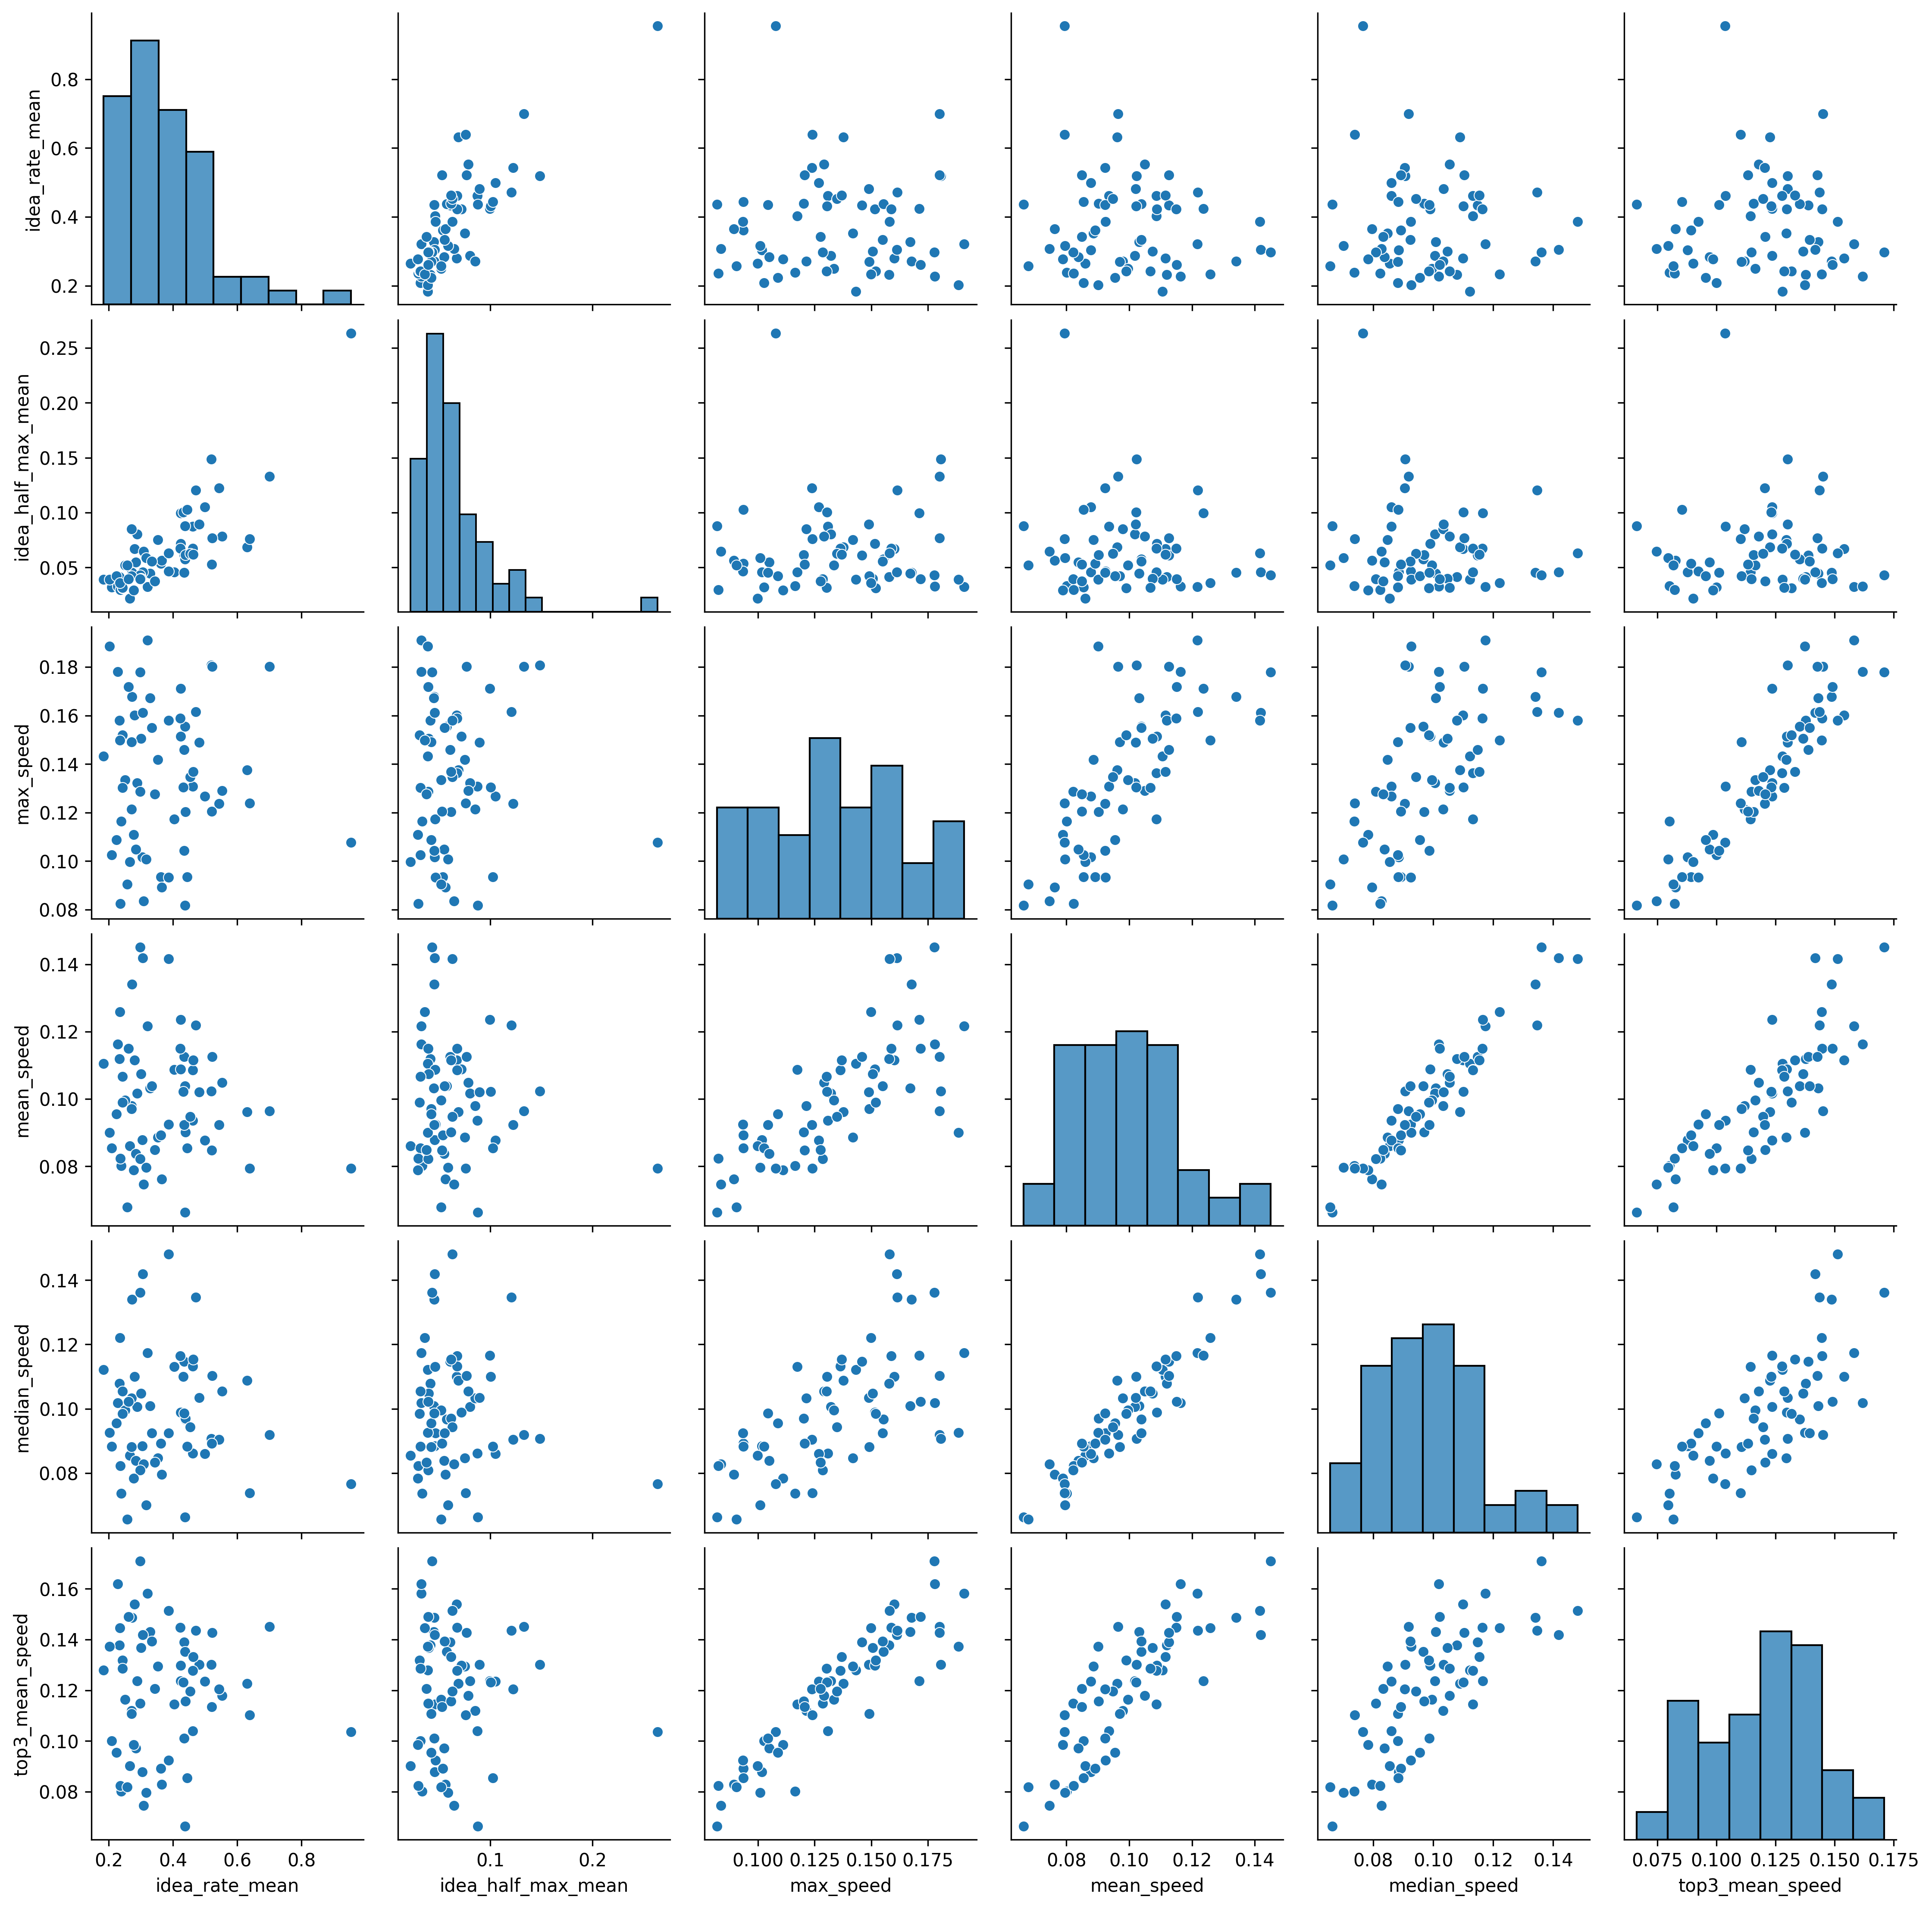

In [119]:
sns.pairplot(idea_trebl_merge[["idea_rate_mean", "idea_half_max_mean", "max_speed", "mean_speed", "median_speed", "top3_mean_speed"]])

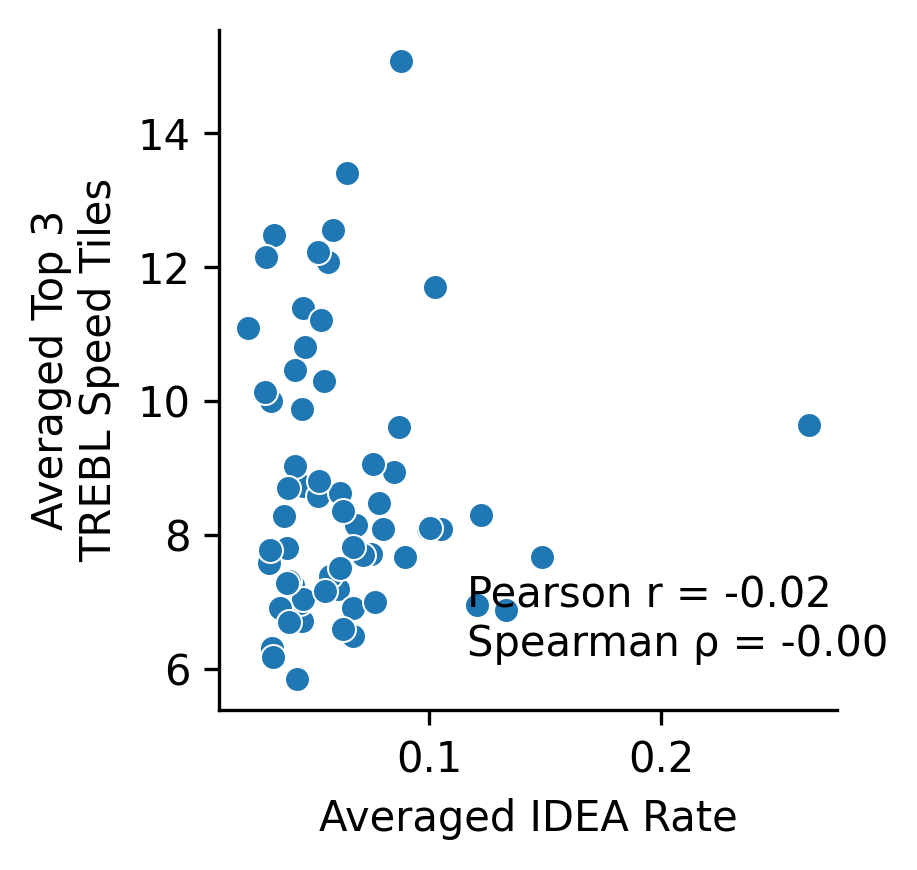

In [122]:
import scipy.stats as stats

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(
    idea_trebl_merge["idea_half_max_mean"],
    idea_trebl_merge["top3_half_max"]
)

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(
    idea_trebl_merge["idea_half_max_mean"],
    idea_trebl_merge["top3_half_max"]
)

# plot
plt.figure(figsize=(3,3))

sns.scatterplot(
    data=idea_trebl_merge,
    x="idea_half_max_mean",
    y="top3_half_max"
)

# add correlation text
plt.text(
    0.4, 0.2,
    (
        f"Pearson r = {pearson_r:.2f}\n"
        f"Spearman ρ = {spearman_r:.2f}"
    ),
    transform=plt.gca().transAxes,
    ha="left",
    va="top"
)

plt.ylabel("Averaged Top 3\nTREBL Speed Tiles")
plt.xlabel("Averaged IDEA Rate")

plt.tight_layout()
sns.despine()
plt.show()

In [132]:
high_conf_idea = idea_trebl_merge[idea_trebl_merge["idea_half_max_std"] < idea_trebl_merge["idea_half_max_mean"]]
high_conf_idea

,gene,idea_rate_mean,idea_rate_std,idea_half_max_mean,idea_half_max_std,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,top3_half_max
0,ACA1,0.238840,0.164639,0.033373,0.029910,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818,12.477178
1,ACE2,0.271665,0.157909,0.045285,0.034899,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,6.724654
3,AFT1,0.328086,0.118077,0.044637,0.022055,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136,6.986966
4,AFT2,0.232428,0.215627,0.041396,0.029549,0.157942,0.111964,0.107917,0.137785,0.026063,8.0,0.823864,7.257702
6,BAS1,0.461226,0.233281,0.087217,0.087041,0.130898,0.093577,0.086097,0.103909,0.022471,5.0,0.738636,9.623829
9,CHA4,0.700171,0.326932,0.133075,0.075958,0.180171,0.096466,0.091852,0.145149,0.038743,12.0,0.965909,6.889455
12,DAL82,0.305527,0.169109,0.045873,0.031727,0.161224,0.141870,0.141870,0.141870,0.027371,2.0,0.454545,7.048685
14,ERT1,0.437084,0.302451,0.087769,0.084488,0.081802,0.066297,0.066297,0.066297,0.021928,2.0,0.454545,15.083666
16,FZF1,0.361895,0.227986,0.053571,0.033733,0.093512,0.089214,0.089214,0.089214,0.006077,2.0,0.255682,11.208959
17,GAL4,0.320841,0.162699,0.032466,0.019821,0.191070,0.121727,0.117372,0.158195,0.029226,11.0,1.107955,6.321313


In [133]:
len(high_conf_idea)

47

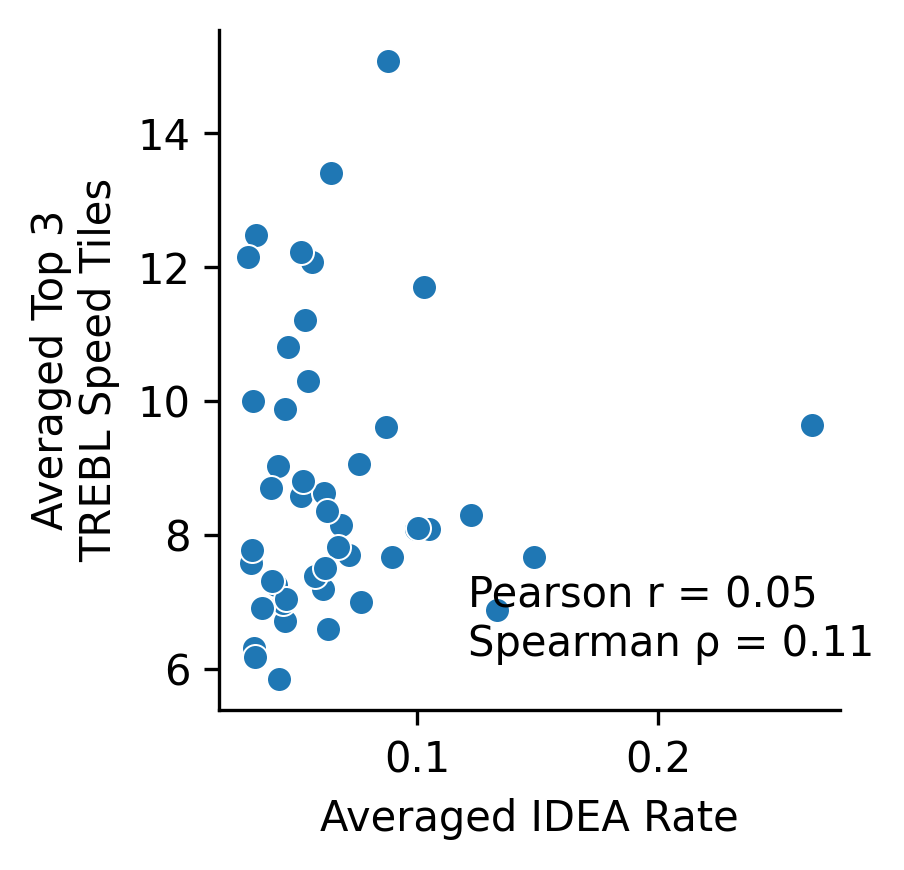

In [134]:
import scipy.stats as stats

# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(
    high_conf_idea["idea_half_max_mean"],
    high_conf_idea["top3_half_max"]
)

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(
    high_conf_idea["idea_half_max_mean"],
    high_conf_idea["top3_half_max"]
)

# plot
plt.figure(figsize=(3,3))

sns.scatterplot(
    data=high_conf_idea,
    x="idea_half_max_mean",
    y="top3_half_max"
)

# add correlation text
plt.text(
    0.4, 0.2,
    (
        f"Pearson r = {pearson_r:.2f}\n"
        f"Spearman ρ = {spearman_r:.2f}"
    ),
    transform=plt.gca().transAxes,
    ha="left",
    va="top"
)

plt.ylabel("Averaged Top 3\nTREBL Speed Tiles")
plt.xlabel("Averaged IDEA Rate")

plt.tight_layout()
sns.despine()
plt.show()

In [136]:
tf_kinetics = (
    idea_kinetics
    .groupby("TF")["half_max"]
    .agg(
        idea_half_max_mean='mean',
        idea_half_max_min='min',
        idea_bottom5_mean=lambda x: x.nsmallest(5).mean(),
        idea_top5_mean=lambda x: x.nlargest(5).mean(),
        idea_trimmed_mean=lambda x: x[(x > x.quantile(0.1)) & (x < x.quantile(0.9))].mean(),
    )
    .reset_index()
)
tf_kinetics

,TF,idea_half_max_mean,idea_half_max_min,idea_bottom5_mean,idea_top5_mean,idea_trimmed_mean
0,ACA1,0.033373,0.014121,0.016185,0.238617,0.026385
1,ACE2,0.045285,0.018149,0.018414,0.320412,0.039890
2,ADA2,0.061820,0.017304,0.021192,0.212930,0.052081
3,ADR1,0.067118,0.017085,0.017794,0.432886,0.035402
4,AFT1,0.044637,0.012776,0.013987,0.225566,0.042795
...,...,...,...,...,...,...
198,YRM1,0.037605,0.017125,0.017554,0.166903,0.026187
199,YRR1,0.052654,0.016543,0.018896,0.191578,0.044689
200,Z3EV,0.176464,0.017202,0.017881,0.390771,0.168027
201,ZAP1,0.058510,0.012510,0.014340,0.238194,0.049782


In [118]:
idea_trebl_merge = pd.merge(average_TF_rates, trebl_speeds)
#idea_trebl_merge["idea_cv"] = idea_trebl_merge["idea_std"] / idea_trebl_merge["idea_mean"]
idea_trebl_merge

,gene,idea_rate_mean,idea_rate_std,idea_half_max_mean,idea_half_max_std,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction,top3_half_max
0,ACA1,0.238840,0.164639,0.033373,0.029910,0.116346,0.080146,0.073654,0.080146,0.033429,3.0,0.681818,12.477178
1,ACE2,0.271665,0.157909,0.045285,0.034899,0.167722,0.134069,0.134059,0.148707,0.023552,5.0,0.625000,6.724654
2,ADR1,0.279771,0.204716,0.067118,0.106766,0.160075,0.111555,0.109937,0.154019,0.025930,21.0,0.329926,6.492688
3,AFT1,0.328086,0.118077,0.044637,0.022055,0.167289,0.103205,0.100838,0.143124,0.029670,15.0,1.051136,6.986966
4,AFT2,0.232428,0.215627,0.041396,0.029549,0.157942,0.111964,0.107917,0.137785,0.026063,8.0,0.823864,7.257702
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,WAR1,0.260614,0.227934,0.039558,0.044084,0.171827,0.115056,0.102160,0.149068,0.035344,7.0,0.982955,6.708348
61,XBP1,0.257143,0.118102,0.052017,0.034122,0.090527,0.067881,0.065601,0.081766,0.017182,6.0,0.795455,12.230064
62,YAP1,0.463372,0.259150,0.061684,0.039944,0.136826,0.111610,0.115328,0.133261,0.018394,13.0,1.250000,7.504083
63,YRM1,0.343128,0.309187,0.037605,0.043460,0.127555,0.084926,0.083371,0.120585,0.030523,14.0,1.505682,8.292879


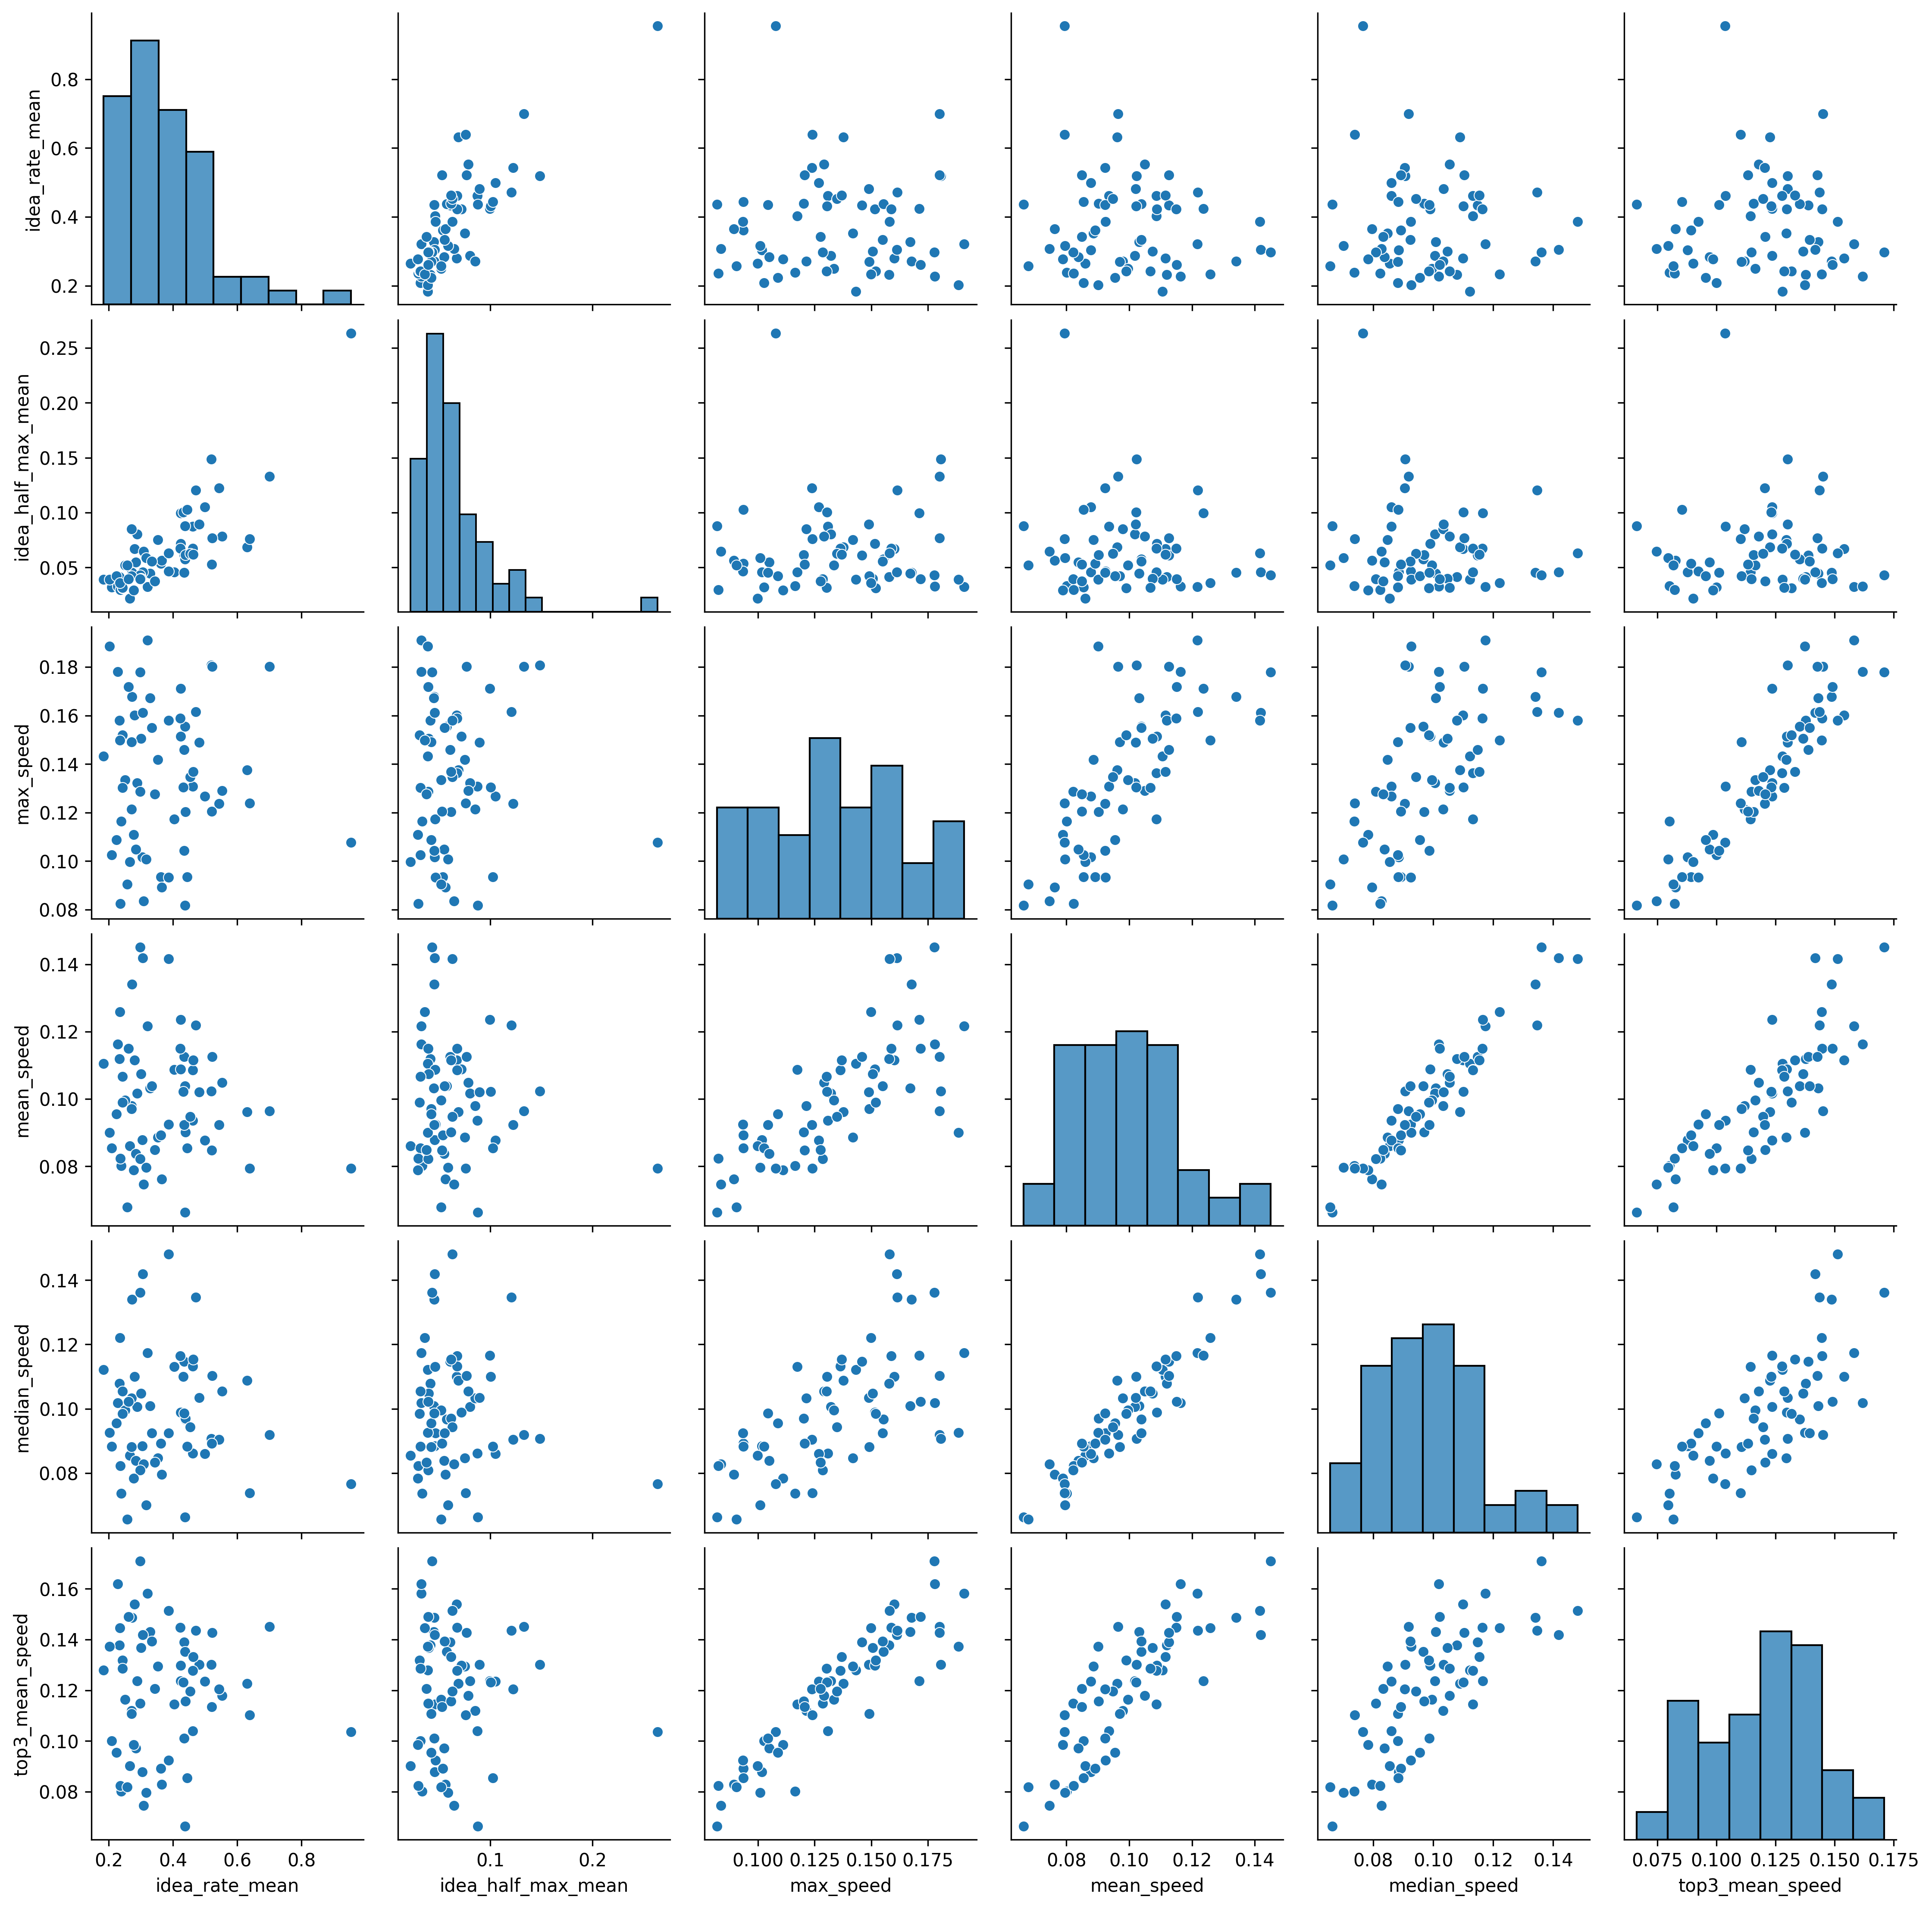

In [119]:
sns.pairplot(idea_trebl_merge[["idea_rate_mean", "idea_half_max_mean", "max_speed", "mean_speed", "median_speed", "top3_mean_speed"]])